In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [63]:
import pandas as pd
df = pd.read_csv("data/StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [64]:
df = pd.get_dummies(df, drop_first=True)  # One-hot encoding


In [65]:
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)


In [66]:
X = df.drop(['math score', 'reading score', 'writing score', 'average_score'], axis=1)
y = df['average_score']


In [67]:
df['pass'] = df['average_score'].apply(lambda x: 1 if x >= 50 else 0)
X = df.drop(['math score', 'reading score', 'writing score', 'average_score', 'pass'], axis=1)
y = df['pass']


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [69]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [70]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)
print("R² Score:", r2_score(y_test, predictions))


RMSE: 0.3315771404845144
R² Score: 0.058502247125776896


In [71]:
df['pass'] = df['average_score'].apply(lambda x: 1 if x >= 50 else 0)


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Redefine the features and target for classification
X = df.drop(['math score', 'reading score', 'writing score', 'average_score'], axis=1)
y = df['pass']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))


Accuracy: 1.0
Confusion Matrix:
 [[ 27   0]
 [  0 173]]


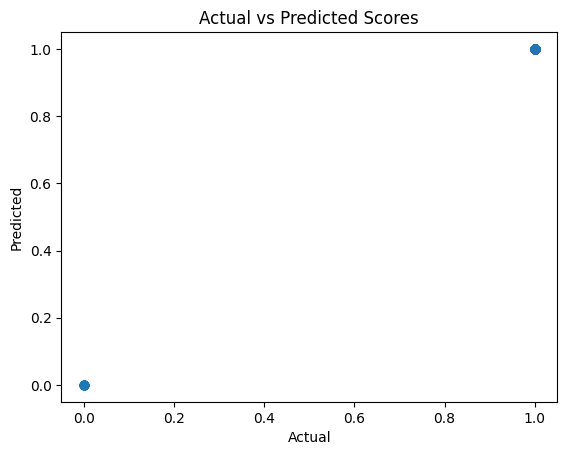

In [73]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Scores")
plt.show()


In [74]:
df['math_reading_interaction'] = df['math score'] * df['reading score']


In [75]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

param_grid = {'fit_intercept': [True, False]}  # Removed 'normalize'
grid_search = GridSearchCV(LinearRegression(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'fit_intercept': True}


In [77]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5)
print(f"Average Cross-validation Score: {cv_scores.mean()}")


Average Cross-validation Score: 1.0


In [78]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, dt_predictions)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")


RMSE: 0.0


In [79]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, rf_predictions)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")


RMSE: 0.0


In [80]:
feature_importances = rf_model.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)


                                          Feature  Importance
12                                           pass         1.0
0                                     gender_male         0.0
1                          race/ethnicity_group B         0.0
2                          race/ethnicity_group C         0.0
3                          race/ethnicity_group D         0.0
4                          race/ethnicity_group E         0.0
5   parental level of education_bachelor's degree         0.0
6         parental level of education_high school         0.0
7     parental level of education_master's degree         0.0
8        parental level of education_some college         0.0
9    parental level of education_some high school         0.0
10                                 lunch_standard         0.0
11                   test preparation course_none         0.0
